# Technique A vs Technique B: geometrification, then conformal 2D mesh

Both techniques turn the same Monte-Carlo grain structure into grain
polygons that `gsmesh2d.mesh_gs` meshes conformally. They differ in how the
polygons are made.

| | Technique A | Technique B |
|---|---|---|
| Notebook | `confMesh2d_mcgs.ipynb` | `confMesh2d_technique_b.ipynb` |
| Class | `polygonised_grain_structure` | `GrainManifold2D` |
| Raw geometry | pixel-exact grain outlines | union of Voronoi cells that share a label |
| Topology | grain-boundary segments split at junction points; each segment is shared by its two grains | none stored; grains share cell vertices |
| Smoothing | shared segments smoothed (`smooth_gbsegs`) | Taubin filter on shared vertices (`smooth_interfaces`) |
| Islands | host polygon with an interior ring, island cut out of it | host hole where the island's cell is |

The comparison uses the **same** label image, the **same** evaluation
window and the **same** mesher and mesh sizes, so the differences come from
the geometry stage alone.

Requires `gmsh` (`pip install upxo[mesh]`).

## 1. Setup and the shared grain structure

In [34]:
import io
import time
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box, Polygon, MultiPolygon
from shapely.ops import unary_union

from upxo.ggrowth.mcgs import mcgs
from upxo.pxtal.geometrification import (polygonised_grain_structure,
                                         GrainManifold2D)
import upxo.gsdataops.grid_ops as gridOps
from upxo.meshing.gsmesh2d import mesh_gs, visualize_gs_mesh
from upxo.viz import gsviz

_XLS = next(
    (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls"
     for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls").is_file()),
    Path("confMesh1.xls"),
)
print("dashboard:", _XLS)

dashboard: c:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls


`SLICE` picks the temporal slice. Early slices (0 to 2) are fine grained: many
single-voxel grains and island grains, which stress both techniques. Later
slices are coarser.

In [ ]:
SLICE = 3
np.random.seed(0)

pxt = mcgs(input_dashboard=str(_XLS))
pxt.simulate()
pxt.detect_grains(library="cc3d", connectivity=4)
gstslice = pxt.gs[list(pxt.gs.keys())[SLICE]]
lgi = gstslice.lgi
h, w = lgi.shape

from upxo._sup.raster_islands import find_island_regions
_, _filled_labels, _ = find_island_regions(lgi)
n_islands = len(np.unique(lgi)) - len(_filled_labels)
print("slice", SLICE, "| image", lgi.shape, "| grains", len(np.unique(lgi)),
      "| island grains:", n_islands)
plt.imshow(lgi, origin="lower", cmap="tab20")
plt.gca().set_aspect("equal")
plt.title("Label image (ground truth)")

## 2. Technique A: pixel-exact polygons, smoothed grain-boundary segments

`pix_to_geom` builds every grain outline from the label image, splits the
boundaries at junction points and assembles rings from shared segments.
Islands are handled by geometrifying the hole-filled structure and each island
cluster separately, then cutting each island out of its host.

In [36]:
t0 = time.perf_counter()
geoA = polygonised_grain_structure(lgi, np.unique(lgi), None)
with contextlib.redirect_stdout(io.StringIO()):
    geoA.pix_to_geom(verbose=False)
tA_raw = time.perf_counter() - t0
with contextlib.redirect_stdout(io.StringIO()):
    geoA.smooth_gbsegs(geoA.GB, npasses=2, max_smooth_levels=np.repeat(2, 2),
                       plot=False, name="s")
tA = time.perf_counter() - t0
cellsA_raw = geoA.GRAINS
cellsA = geoA.smoothed["s"]["GRAINS"]
print(f"Technique A: {len(cellsA)} grains, geometrify {tA_raw:.1f} s, "
      f"total with smoothing {tA:.1f} s")

Technique A: 162 grains, geometrify 0.3 s, total with smoothing 0.4 s


## 3. Technique B: Voronoi cells unioned by label, Taubin-smoothed

Seeds are dense along grain boundaries and coarser in the bulk. Each seed takes
the label of the pixel it lands in and the cells that share a label are unioned.

In [37]:
t0 = time.perf_counter()
seeds = gridOps.generate_constrained_hybrid_seeds(
    lgi, target_spacing=1.0, bulk_spacing=1.0,
    jitter_factor=0.25, margin=0.5, padding=2.0)
manifold = GrainManifold2D.by_tessellation(lgi, seeds)
cellsB_raw = dict(manifold.cells)
manifold.smooth_interfaces(iterations=10, lmbda=0.5, mu=-0.53)
cellsB = dict(manifold.cells)
tB = time.perf_counter() - t0
print(f"Technique B: {len(cellsB)} grains, {len(seeds)} seeds, "
      f"total with smoothing {tB:.1f} s")

Technique B: 162 grains, 1757 seeds, total with smoothing 0.4 s


## 4. A common evaluation window

The outer strip is removed from both, since Technique B's cells leak past the
domain edge before trimming. Pixel `(row, col)` is the square centred on
`(col, row)`, which is the convention of both techniques. The reference for
every grain is its pixel count inside the window.

In [38]:
pad = max(2, min(h, w) // 10)
win = box(pad - 0.5, pad - 0.5, w - pad - 0.5, h - pad - 0.5)
sub = lgi[pad:h - pad, pad:w - pad]
truth = {int(g): int(n) for g, n in zip(*np.unique(sub, return_counts=True))}


def polys_of(geom):
    if isinstance(geom, Polygon):
        return [geom]
    if hasattr(geom, "geoms"):
        return [p for g in geom.geoms for p in polys_of(g)]
    return []


def clip(cells):
    out = {}
    for g, geom in cells.items():
        ps = [p for p in polys_of(geom.intersection(win)) if p.area > 0]
        if ps:
            out[g] = unary_union(ps)
    return out


def aspect(geom):
    p = max(polys_of(geom), key=lambda q: q.area)
    c = list(p.minimum_rotated_rectangle.exterior.coords)
    a = np.hypot(c[1][0] - c[0][0], c[1][1] - c[0][1])
    b = np.hypot(c[2][0] - c[1][0], c[2][1] - c[1][1])
    return max(a, b) / max(min(a, b), 1e-9)


def metrics(cells):
    clipped = clip(cells)
    ids = sorted(truth)
    area = np.array([clipped[g].area if g in clipped else 0.0 for g in ids])
    px = np.array([truth[g] for g in ids], dtype=float)
    err = np.abs(area - px) / px
    single = [i for i, g in enumerate(ids) if truth[g] == 1]
    union = unary_union(list(clipped.values()))
    return {
        "grains in reference": len(ids),
        "grains present": int((area > 0).sum()),
        "grains missing": int((area == 0).sum()),
        "area error, mean": float(err.mean()),
        "area error, 95th percentile": float(np.percentile(err, 95)),
        "area error, max": float(err.max()),
        "single-pixel grains": len(single),
        "single-pixel kept (0.5 to 1.5 px)": int(((area[single] > 0.5) &
                                                  (area[single] < 1.5)).sum()),
        "slender grains (aspect > 3)": int(sum(aspect(g) > 3
                                               for g in clipped.values())),
        "window covered": float(union.area / win.area),
        "overlap area": float(sum(g.area for g in clipped.values())
                              - union.area),
        "grains with an interior ring": int(sum(
            len(list(p.interiors)) > 0
            for g in clipped.values() for p in polys_of(g))),
    }, clipped, err


mA, clipA, errA = metrics(cellsA)
mB, clipB, errB = metrics(cellsB)
mA_raw, _, _ = metrics(cellsA_raw)
mB_raw, _, _ = metrics(cellsB_raw)
geom_table = pd.DataFrame({"A raw": mA_raw, "A smoothed": mA,
                           "B raw": mB_raw, "B smoothed": mB})
geom_table.style.format("{:.4g}") if hasattr(geom_table, "style") else geom_table

,A raw,A smoothed,B raw,B smoothed
grains in reference,108,108,108,108
grains present,108,108,108,108
grains missing,0,0,0,0
"area error, mean",0,0.09767,0,0.03199
"area error, 95th percentile",0,0.2778,0,0.1188
"area error, max",0,0.7037,0,0.3105
single-pixel grains,17,17,17,17
single-pixel kept (0.5 to 1.5 px),17,14,17,17
slender grains (aspect > 3),1,3,1,5
window covered,1,1,1,1


Reading the table: *raw* is before smoothing. Smoothing is expected to change
grain areas somewhat, so read the *smoothed* columns for the geometry that is
actually meshed. *grains missing* and *single-pixel kept* show whether small
features survive, and *overlap area* with *window covered* show whether the
grains tile the window.

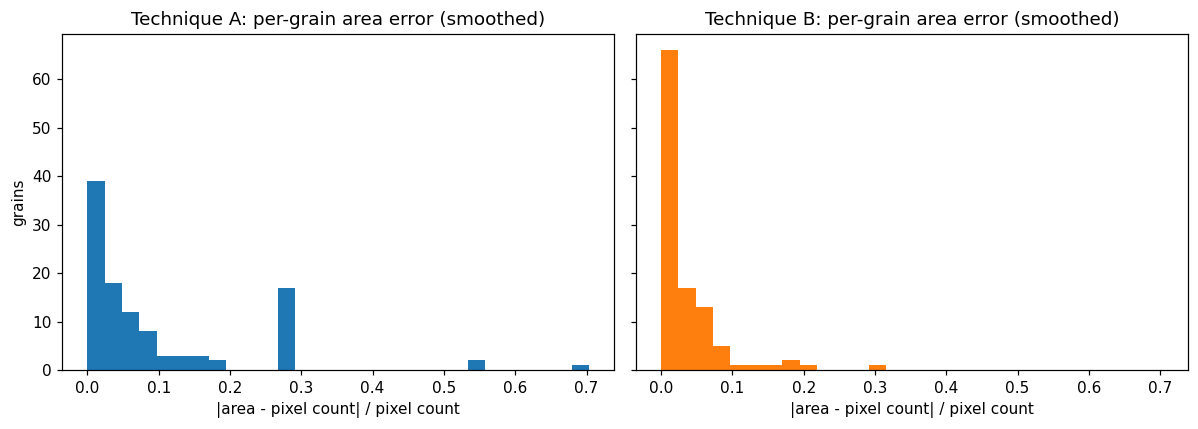

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=110, sharey=True)
bins = np.linspace(0, max(errA.max(), errB.max(), 1e-9), 30)
for ax, e, name in zip(axes, (errA, errB), ("Technique A", "Technique B")):
    ax.hist(e, bins=bins, color="tab:blue" if name.endswith("A") else "tab:orange")
    ax.set_title(f"{name}: per-grain area error (smoothed)")
    ax.set_xlabel("|area - pixel count| / pixel count")
axes[0].set_ylabel("grains")
fig.tight_layout()

## 5. Side-by-side geometry

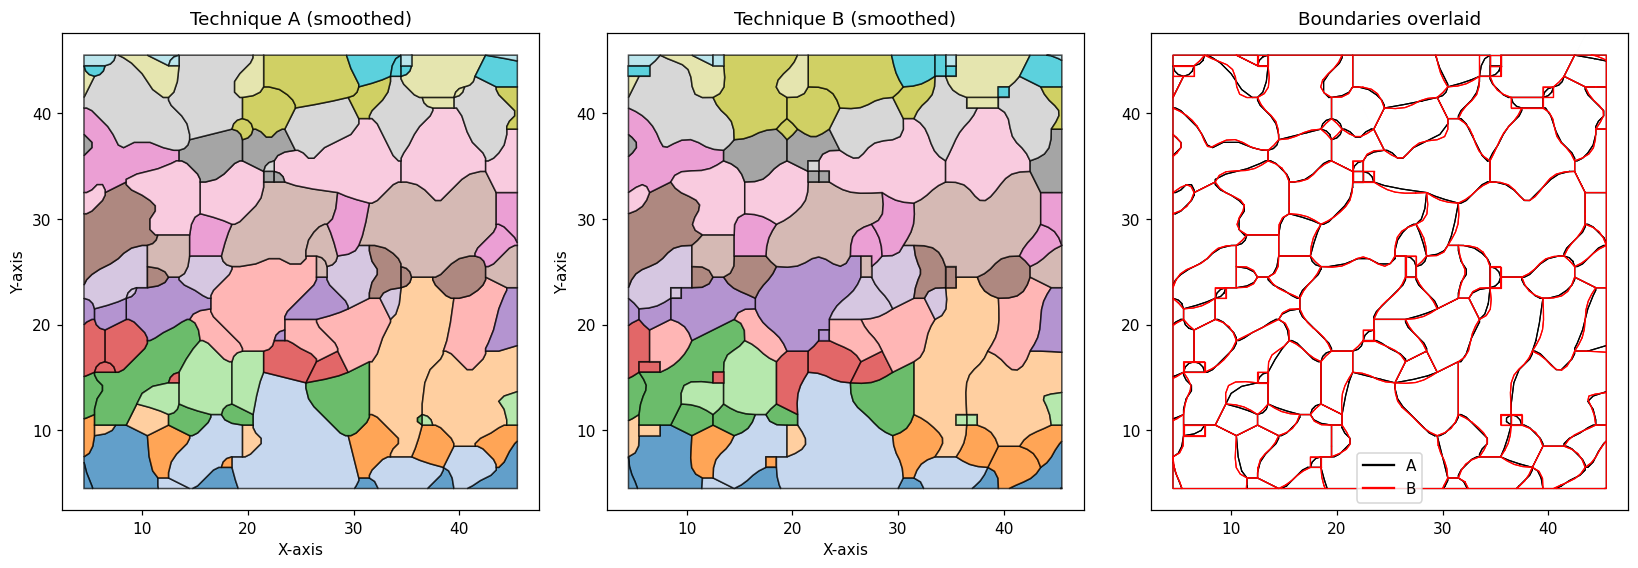

In [40]:
def to_multipolygon(cells):
    return MultiPolygon([p for g in cells.values() for p in polys_of(g)])


fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=110)
gsviz.plot_multipolygon_geometric(to_multipolygon(clipA), fig=fig, ax=axes[0])
axes[0].set_title("Technique A (smoothed)")
gsviz.plot_multipolygon_geometric(to_multipolygon(clipB), fig=fig, ax=axes[1])
axes[1].set_title("Technique B (smoothed)")
for cells, color, label in ((clipA, "black", "A"), (clipB, "red", "B")):
    for geom in cells.values():
        for p in polys_of(geom):
            axes[2].plot(*p.exterior.xy, color=color, lw=0.8)
            for r in p.interiors:
                axes[2].plot(*r.xy, color=color, lw=0.8)
axes[2].plot([], [], color="black", label="A")
axes[2].plot([], [], color="red", label="B")
axes[2].legend()
axes[2].set_aspect("equal")
axes[2].set_title("Boundaries overlaid")
fig.tight_layout()

## 6. Conformal mesh with the same mesher and sizes

Both polygon sets, clipped to the common window, go through the same
`mesh_gs` call.

In [41]:
def mesh(cells):
    t0 = time.perf_counter()
    with contextlib.redirect_stdout(io.StringIO()):
        res = mesh_gs(cells, mesh_size_gb=1.5, mesh_size_bulk=3.0,
                      mesh_algo=6, recombine_to_quads=False, verbose=False)
        m = res["mesher"]
        m.form_elsets_gmsh()
    dt = time.perf_counter() - t0
    vr, q, f = m.validation_report, m.quality_report, m.fidelity_report
    return res, {
        "nodes": res["n_nodes"],
        "triangles": res["n_tri"],
        "grains with elements": int(sum(v > 0 for v in
                                        vr["grain_element_counts"].values())),
        "grains without elements": len(vr["grains_missing_elements"]),
        "inverted elements": vr["clockwise_elements"],
        "degenerate elements": vr["degenerate_elements"],
        "min angle (deg)": min(s["min"] for s in q["min_angle_deg"].values()),
        "mean min-angle (deg)": float(np.mean(
            [s["mean"] for s in q["min_angle_deg"].values()])),
        "max aspect ratio": max(s["max"] for s in q["aspect_ratio"].values()),
        "max grain-area error vs polygons": f["max_area_rel_error"],
        "meshing time (s)": dt,
    }


resA, mesh_A = mesh(clipA)
resB, mesh_B = mesh(clipB)
mesh_table = pd.DataFrame({"A": mesh_A, "B": mesh_B})
mesh_table

,A,B
nodes,2.167000e+03,2.050000e+03
triangles,4.197000e+03,3.964000e+03
grains with elements,1.090000e+02,1.100000e+02
grains without elements,0.000000e+00,0.000000e+00
inverted elements,0.000000e+00,0.000000e+00
degenerate elements,0.000000e+00,0.000000e+00
min angle (deg),9.462321e+00,2.067457e+00
mean min-angle (deg),4.444071e+01,4.668539e+01
max aspect ratio,6.082763e+00,2.750731e+01
max grain-area error vs polygons,2.850028e-13,2.129003e-12


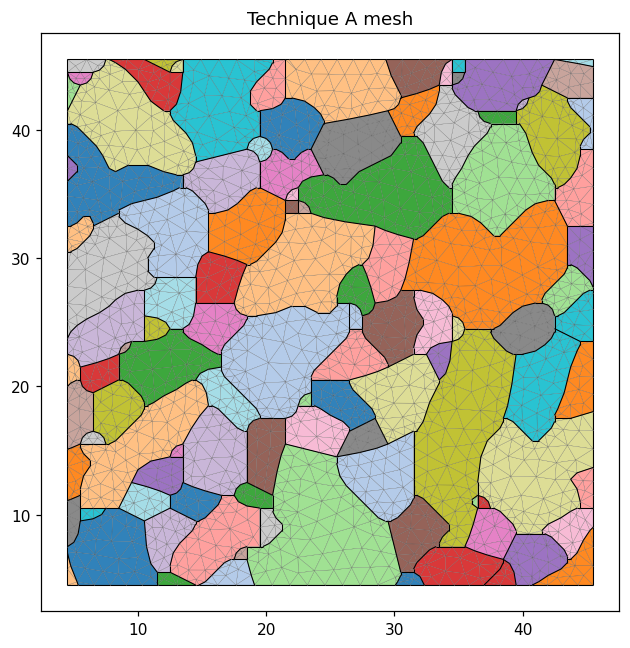

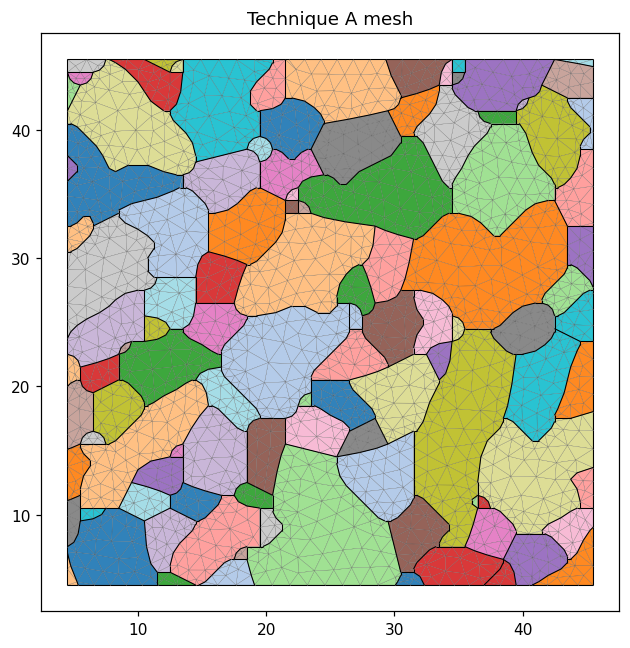

In [42]:
figA, axA = visualize_gs_mesh(resA, figsize=(6, 6), dpi=110, show_nsets=False)
axA.set_title("Technique A mesh")
figA

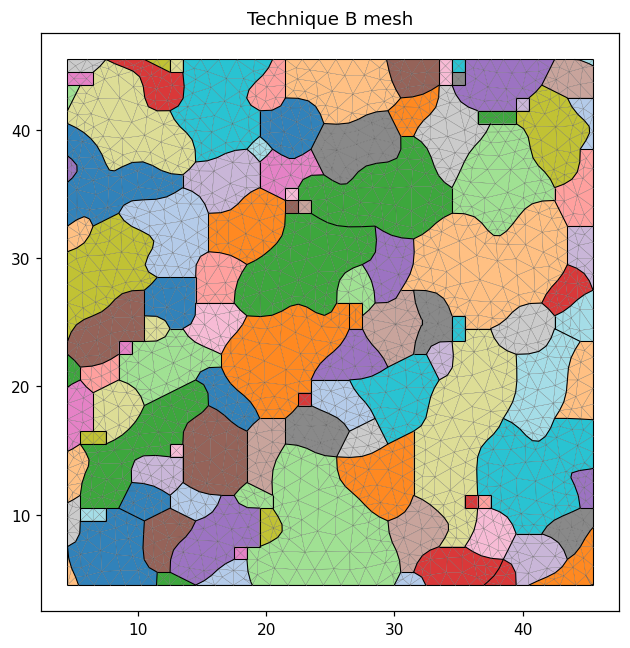

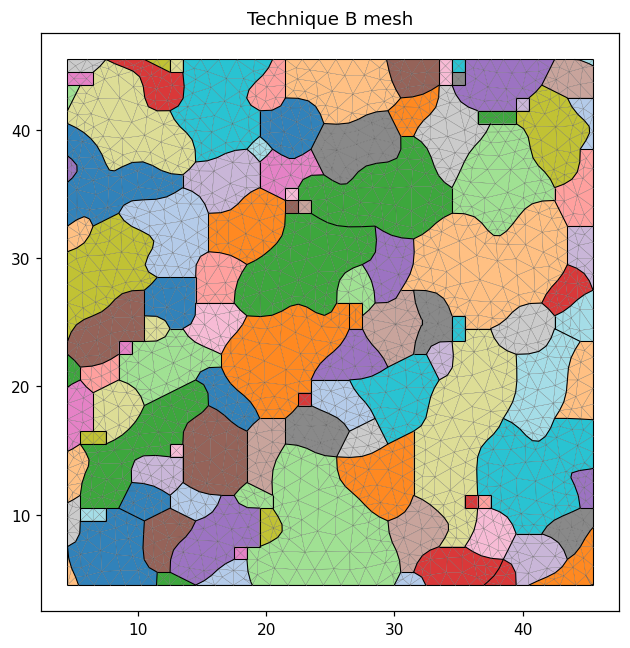

In [43]:
figB, axB = visualize_gs_mesh(resB, figsize=(6, 6), dpi=110, show_nsets=False)
axB.set_title("Technique B mesh")
figB

## 7. Timing

Both techniques were sped up significantly in the session that built this
notebook (roughly 15x for Technique A, roughly 25% for Technique B, from
their original implementations), so read the tables above as current, not
as a historical baseline.

Which is faster now depends on the grain structure, not just grain count:

* On large, fairly uniform structures (similar grain sizes, few islands),
  Technique A is typically **faster** than Technique B, by a growing margin
  as grain count increases: both costs are now roughly linear in grain
  count, but Technique A's per-grain cost is lower.
* On small, irregular structures with many islands and single-pixel grains
  (the early MCGS slices this notebook favours), neither technique has a
  reliable edge: the ordering can go either way, since both now carry extra
  fixed per-grain / per-island bookkeeping that dominates at this scale.

Read the tables above for the actual answer on the slice you are using,
rather than assume one technique is always faster.

In [44]:
pd.DataFrame({"geometry + smoothing (s)": {"A": tA, "B": tB},
              "meshing (s)": {"A": mesh_A["meshing time (s)"],
                              "B": mesh_B["meshing time (s)"]}})

,geometry + smoothing (s),meshing (s)
A,0.401652,0.176923
B,0.410045,0.177781


## How to choose

* Use **Technique A** when the grain outlines must follow the label image
  exactly, when shared grain-boundary segments and junction points are wanted
  (for example to attach boundary properties), or when island grains must be
  represented as a host polygon with an interior ring.
* Use **Technique B** when a smooth Voronoi-based interface is preferred over
  a pixel-derived one. Do not pick it for speed by default: see the Timing
  section above — Technique A is now typically faster on large, uniform
  structures, and neither is reliably faster on small, irregular ones.
* For either, look at *single-pixel kept*, *grains missing* and *overlap area*
  above on the slice you actually use. Early, fine-grained slices are where the
  techniques differ most.